# From a P&L path to a ranking label

This notebook isolates the P&L shaping in [v2](harvesting_vrp_synthetic_v2.ipynb)
and the [paper](../../docs/research/papers/Harvesting_the_Volatility_Risk_Premium_A_Learning_to_Rank_Approach.md).
Run it top to bottom, then edit the last example to try your own path.

The sequence is **P&L increments → total profit and downside → continuous
path score → frozen training bins → relevance grade → ranking gain**.
The continuous path score is a *realized training target*. It is different from
the score LightGBM predicts from features before a trade starts.

We use small, hand-written numbers so every calculation is visible. The main
examples have ten daily increments, matching your maximum holding period;
an earlier expiry simply supplies a shorter, completed path. These values are
illustrative P&L units for a fixed opening-risk allocation, not realistic return
estimates. No model fitting or market download is needed here.

In [1]:
import os
import sys
from pathlib import Path

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents]
            if (p / 'docs/spec.md').exists())
cache = ROOT / 'tmp/pnl_shaping_cache'
cache.mkdir(parents=True, exist_ok=True)
os.environ.setdefault('MPLCONFIGDIR', str(cache / 'matplotlib'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

EPSILON = 1e-8  # Paper and v2, not an adjustable risk penalty.
GRADE_QUANTILES = [.10, .40, .60, .90]  # Paper and v2.
GAIN = np.array([0, 1, 3, 7, 15])  # Paper's LambdaRank label gains.
print('Python:', sys.executable)

Python: /Users/constantinpavlicu/dev/apollo3/venv/bin/python


## 1. Start with changes in P&L, not cumulative P&L

For a short put, a falling option mark makes money and a rising mark loses
money: $d_i=m_{i-1}-m_i$. The little mark sequence below ends with a worthless
option at expiry. It illustrates sign and differencing, not a full pricing model.

In v2 these increments already come from the signed daily UPNL flow:
`gross_per_risk = structure_weight * pnlOpt * fx_price / entry_risk_usd`.
Qbit's source `pnlOpt` is already rtvega-normalized: **do not multiply by source
quantity or undo that normalization again**. V2's denominator converts the
source exposure to a common opening USD-risk allocation. The label is gross;
costs enter the separate net P&L used for portfolio evaluation/calibration.

In [2]:
option_marks = pd.Series([5., 4., 6., 3., 0.], name='option_mark')
mark_example = option_marks.to_frame()
mark_example['short_pnl_increment'] = -option_marks.diff()
mark_example['cumulative_short_pnl'] = option_marks.iloc[0]-option_marks
mark_example.index.name = 'mark_number'
display(mark_example)
print('Total short P&L:', mark_example.short_pnl_increment.sum())

,option_mark,short_pnl_increment,cumulative_short_pnl
mark_number,,,
0,5.0,NaN,0.0
1,4.0,1.0,1.0
2,6.0,-2.0,-1.0
3,3.0,3.0,2.0
4,0.0,3.0,5.0


Total short P&L: 5.0


## 2. The complete scoring formula

For the completed gross P&L increments $d_1,\ldots,d_N$:

$$G=\sum_i d_i,\qquad D=\sqrt{\sum_i \min(d_i,0)^2},\qquad
z=\frac{G}{D+10^{-8}}.$$

- **Numerator:** add all increments to get total gross P&L.
- **Denominator:** keep only negative increments, square them, add them, then
  take the square root. Positive increments contribute zero to this part.
- **Score:** divide the total by that downside measure. Larger scores rank higher.

There is no average, subtraction of a mean, annualization or division by the
number of observations. $D$ is neither a standard deviation nor a maximum
drawdown. This trade label is also different from the portfolio Sortino used
later to calibrate the confidence gate.

In [3]:
def shape_pnl(increments):
    """Score one complete, finite path of signed gross P&L increments."""
    d = np.asarray(increments, dtype=float)
    if d.ndim != 1 or d.size == 0 or not np.isfinite(d).all():
        raise ValueError('Supply a nonempty, complete 1-D path of finite increments')
    gross = d.sum()
    downside = np.sqrt(np.square(np.minimum(d, 0)).sum())
    return {'gross': gross, 'downside': downside,
            'z': gross/(downside+EPSILON)}


examples = {
    'No losing day':            [2, 2, 2, 2, 2, 2, 2, 2, 2, 2],
    'Small scattered losses':  [4, -1, 4, -1, 4, -1, 4, -1, 4, 4],
    'Same losses first':       [-1, -1, -1, -1, 4, 4, 4, 4, 4, 4],
    'One deep loss':           [5, 5, 5, 5, -10, 2, 2, 2, 2, 2],
    'More profit, more risk':  [10, 10, -20, 10, 10, 2, 2, 2, 2, 2],
    'Break-even trade':        [5, -5, 0, 0, 0, 0, 0, 0, 0, 0],
    'Steady losing trade':     [-1, -1, -1, -1, -1, -1, -1, -1, -1, -1],
    'Volatile losing trade':   [10, -20, 0, 0, 0, 0, 0, 0, 0, 0],
    'SKIP':                    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
}
increments = pd.DataFrame(examples, index=pd.RangeIndex(1, 11, name='day'))
summary = pd.DataFrame({name: shape_pnl(path) for name, path in examples.items()}).T
summary.index.name = 'candidate_scenario'
display(increments.T)
display(summary.sort_values('z', ascending=False).style.format(
    {'gross': '{:.2f}', 'downside': '{:.6g}', 'z': '{:.6g}'}))

day,1,2,3,4,5,6,7,8,9,10
No losing day,2,2,2,2,2,2,2,2,2,2
Small scattered losses,4,-1,4,-1,4,-1,4,-1,4,4
Same losses first,-1,-1,-1,-1,4,4,4,4,4,4
One deep loss,5,5,5,5,-10,2,2,2,2,2
"More profit, more risk",10,10,-20,10,10,2,2,2,2,2
Break-even trade,5,-5,0,0,0,0,0,0,0,0
Steady losing trade,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1
Volatile losing trade,10,-20,0,0,0,0,0,0,0,0
SKIP,0,0,0,0,0,0,0,0,0,0


,gross,downside,z
candidate_scenario,,,
No losing day,20.00,0,2e+09
Small scattered losses,20.00,2,10
Same losses first,20.00,2,10
One deep loss,20.00,10,2
"More profit, more risk",30.00,20,1.5
Break-even trade,0.00,5,0
SKIP,0.00,0,0
Volatile losing trade,-10.00,20,-0.5
Steady losing trade,-10.00,3.16228,-3.16228


## 3. Work through one score by hand

“Small scattered losses” earns $6\times4-4\times1=20$.
Its four losses each contribute $(-1)^2=1$ to the squared-downside sum:
$D=\sqrt{4}=2$, so $z=20/(2+10^{-8})\approx10$.

“One deep loss” also earns 20, but $D=10$, so its score is approximately 2.
“More profit, more risk” earns 30, yet scores only $30/20\approx1.5$.
**The highest gross P&L need not have the highest training score.**

,d_i,negative_part,negative_squared,cumulative_gross
day,,,,
1,4,0,0,4
2,-1,-1,1,3
3,4,0,0,7
4,-1,-1,1,6
5,4,0,0,10
6,-1,-1,1,9
7,4,0,0,13
8,-1,-1,1,12
9,4,0,0,16


Sum of squared negative increments: 4
Gross, downside and score: {'gross': np.float64(20.0), 'downside': np.float64(2.0), 'z': np.float64(9.999999950000001)}


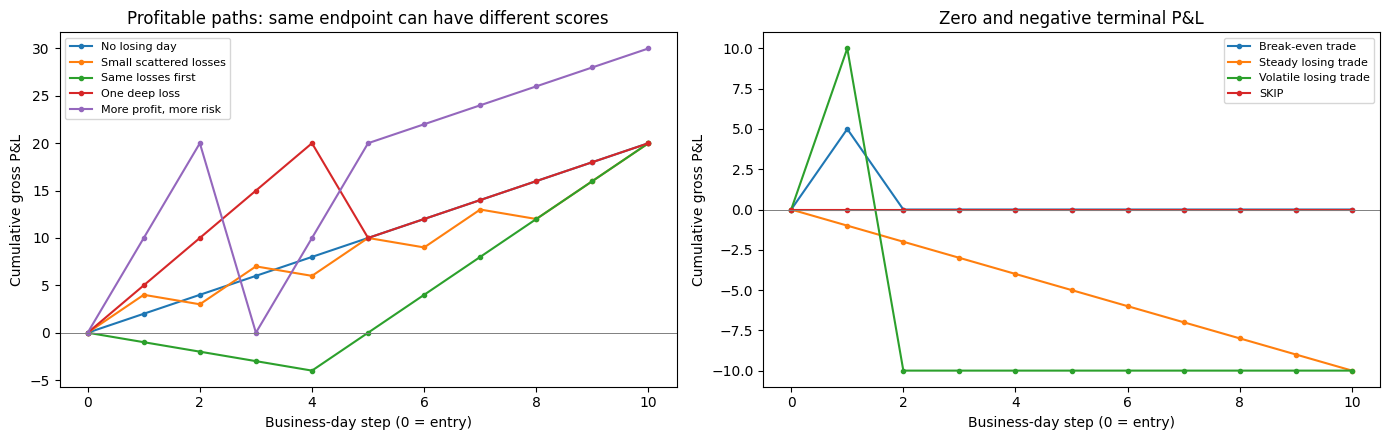

In [4]:
worked = increments[['Small scattered losses']].rename(columns={'Small scattered losses': 'd_i'})
worked['negative_part'] = worked.d_i.clip(upper=0)
worked['negative_squared'] = worked.negative_part**2
worked['cumulative_gross'] = worked.d_i.cumsum()
display(worked)
print('Sum of squared negative increments:', worked.negative_squared.sum())
print('Gross, downside and score:', shape_pnl(worked.d_i))

# The entry mark is zero P&L; prepend it to show the complete cumulative path.
cumulative = pd.concat([pd.DataFrame(0., index=[0], columns=increments.columns), increments]).cumsum()
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for ax, names, title in [
    (axes[0], list(examples)[:5], 'Profitable paths: same endpoint can have different scores'),
    (axes[1], list(examples)[5:], 'Zero and negative terminal P&L'),
]:
    for name in names:
        ax.plot(cumulative.index, cumulative[name], marker='.', label=name)
    ax.axhline(0, color='grey', linewidth=.7)
    ax.set(xlabel='Business-day step (0 = entry)', ylabel='Cumulative gross P&L', title=title)
    ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

## 4. What this shaping does — and does not — reward

**No losses:** “No losing day” has $D=0$, so $z=20/10^{-8}=2\times10^9$.
The epsilon prevents division by zero; it does not cap the score. The later
grade transformation compresses this large value into one of five categories.
An all-zero SKIP path instead has $0/10^{-8}=0$.

**Break-even trades:** a risky trade ending at zero also gets $z=0$, just like
SKIP. The label does not separately penalize its risk once the numerator is zero.

**Losing trades:** both losing examples finish at −10. Their scores are about
−3.162 and −0.5. The volatile loser ranks *higher*, because a larger denominator
makes a negative fraction closer to zero. “Penalize downside” describes the
positive-profit case; it is not a universal ordering rule for negative profits.

**Order:** rearranging identical increments leaves $G$ and $D$ unchanged.
The two small-loss paths have the same score, although their maximum drawdowns
differ. The label sees negative increments, not the full sequence of drawdowns.

In [5]:
order_comparison = summary.loc[['Small scattered losses', 'Same losses first']].copy()
for name in order_comparison.index:
    curve = cumulative[name]
    order_comparison.loc[name, 'max_drawdown_pnl_units'] = (curve.cummax()-curve).max()
display(order_comparison)

# A constant positive position multiplier nearly cancels, except for epsilon.
scale_example = pd.DataFrame({
    'Original path': shape_pnl(examples['One deep loss']),
    'Ten times the position': shape_pnl(10*np.array(examples['One deep loss'])),
}).T
display(scale_example)

# Identical gross label, different net outcome. These are illustrative total costs.
cost_example = pd.DataFrame({'illustrative_cost': [1., 25.]})
cost_example['gross'] = summary.loc['Small scattered losses', 'gross']
cost_example['net'] = cost_example.gross-cost_example.illustrative_cost
cost_example['label_z'] = summary.loc['Small scattered losses', 'z']
display(cost_example)

,gross,downside,z,max_drawdown_pnl_units
candidate_scenario,,,,
Small scattered losses,20.0,2.0,10.0,1.0
Same losses first,20.0,2.0,10.0,4.0


,gross,downside,z
Original path,20.0,10.0,2.0
Ten times the position,200.0,100.0,2.0


,illustrative_cost,gross,net,label_z
0,1.0,20.0,19.0,10.0
1,25.0,20.0,-5.0,10.0


Scaling every increment by a positive constant almost cancels between numerator
and denominator when $D>0$; the fixed epsilon makes this approximate. This does
not hold in the loss-free $D=0$ case. Fees are deliberately outside the label:
the cost example can become net negative while retaining the same gross score.

**Sampling matters.** Aggregating marks can hide losing intervals. The example
below groups four increments into two blocks. Profit remains 2, but the coarse
series has no losses and receives a huge score. The paper uses minute marks;
v2 uses daily marks. The formula is the same, but these are different labels.
There is also no explicit correction for a path exiting in five rather than ten
business days. Use its actual observed increments; do not invent missing marks.

In [6]:
fine_path = np.array([2., -1., 2., -1.])
coarse_path = fine_path.reshape(-1, 2).sum(axis=1)
frequency_example = pd.DataFrame({
    'Four observed increments': shape_pnl(fine_path),
    'Two aggregated increments': shape_pnl(coarse_path),
}).T
frequency_example['increments'] = [fine_path.tolist(), coarse_path.tolist()]
display(frequency_example)

,gross,downside,z,increments
Four observed increments,2.0,1.414214,1.414214e+00,"[2.0, -1.0, 2.0, -1.0]"
Two aggregated increments,2.0,0.000000,2.000000e+08,"[1.0, 1.0]"


## 5. Fit the grade boundaries on completed training trades

LightGBM LambdaRank receives **integer relevance grades 0–4**, not the continuous
$z$ values. Pool $z$ across all real candidates and dates in the fitting window,
excluding SKIP, and estimate the 10%, 40%, 60% and 90% quantiles. Freeze them for
that fitted model. V2 uses pandas linear interpolation; the paper does not
specify an interpolation rule.

Below is a deliberately small training history with **14 real candidates plus
SKIP per entry date**. Each real path starts with a −4 increment; the remaining
nine increments produce the listed gross outcome. These invented outcomes only
make the transformation easy to inspect. They are not model thresholds.

The fitting boundary is 1 January 2024. Two queries have completed; the late
December query has not. Its eventual outcomes are shown for this retrospective
demonstration but excluded from fitting. As in v2, an unfinished candidate
excludes its whole query. Dates use the same illustrative weekday clock as v2;
real label availability comes from actual expiry/exit records and calendars.

,real_candidates,label_available,used_for_cuts
date,,,
2023-11-01,14,2023-11-15,14
2023-12-01,14,2023-12-15,14
2023-12-29,14,2024-01-12,0


,date,secId,gross,downside,z
0,2023-11-01,1,-8.0,4.216370,-1.897367
1,2023-11-01,2,-5.0,4.013865,-1.245682
2,2023-11-01,3,-2.0,4.000000,-0.500000
3,2023-11-01,4,0.0,4.000000,0.000000
4,2023-11-01,5,1.0,4.000000,0.250000
5,2023-11-01,6,2.0,4.000000,0.500000
6,2023-11-01,7,3.0,4.000000,0.750000
7,2023-11-01,8,4.0,4.000000,1.000000
8,2023-11-01,9,6.0,4.000000,1.500000
9,2023-11-01,10,8.0,4.000000,2.000000


,frozen_score_cutpoint
0.1,-1.315855
0.4,0.450000
0.6,1.300000
0.9,3.825000


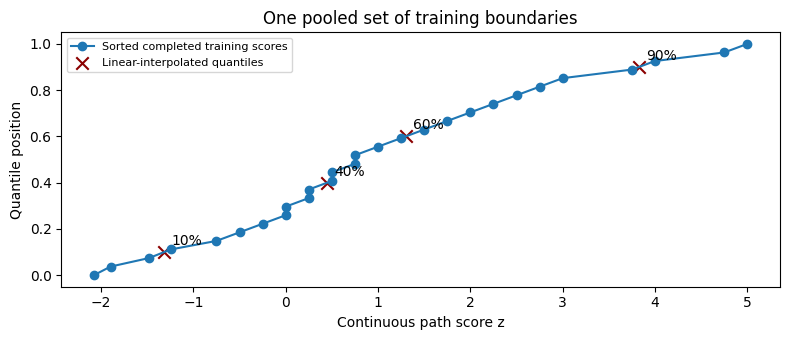

In [7]:
FIT_BOUNDARY = pd.Timestamp('2024-01-01')  # Illustrative historical fit boundary.
toy_gross = np.array([-8., -5., -2., 0., 1., 2., 3., 4., 6., 8., 10., 12., 16., 20.])
historical_rows = []
for date_text, profit_shift in [('2023-11-01', 0.), ('2023-12-01', -1.), ('2023-12-29', 0.)]:
    date = pd.Timestamp(date_text)
    exit_date = date+pd.offsets.BDay(10)
    for sec_id, gross in enumerate(toy_gross+profit_shift, start=1):
        path = [-4.] + [(gross+4.)/9]*9
        historical_rows.append(dict(date=date, secId=sec_id, label_available=exit_date,
                                    **shape_pnl(path)))
    historical_rows.append(dict(date=date, secId=pd.NA, label_available=exit_date,
                                **shape_pnl(np.zeros(10))))
historical = pd.DataFrame(historical_rows)
historical['secId'] = historical.secId.astype('Int64')  # Missing ID denotes SKIP.
query_complete = historical.label_available.lt(FIT_BOUNDARY).groupby(historical.date).transform('all')
historical['used_for_cuts'] = historical.date.lt(FIT_BOUNDARY) & query_complete & historical.secId.notna()
training_scores = historical.loc[historical.used_for_cuts, 'z']
cuts = training_scores.quantile(GRADE_QUANTILES, interpolation='linear').to_numpy()


def grades(z, cuts):
    # Exact v2 convention: equality with a cut stays in the lower grade.
    return np.searchsorted(cuts, np.asarray(z), side='left').astype(np.int32)


display(historical.groupby('date').agg(
    real_candidates=('secId', 'count'), label_available=('label_available', 'max'),
    used_for_cuts=('used_for_cuts', 'sum')))
display(historical.loc[historical.used_for_cuts, ['date', 'secId', 'gross', 'downside', 'z']])
display(pd.Series(cuts, index=GRADE_QUANTILES, name='frozen_score_cutpoint').to_frame())

sorted_scores = np.sort(training_scores)
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(sorted_scores, np.linspace(0, 1, len(sorted_scores)), 'o-', label='Sorted completed training scores')
ax.scatter(cuts, GRADE_QUANTILES, marker='x', s=80, color='darkred', label='Linear-interpolated quantiles')
for quantile, cut in zip(GRADE_QUANTILES, cuts):
    ax.annotate(f'{quantile:.0%}', (cut, quantile), xytext=(5, 5), textcoords='offset points')
ax.set(xlabel='Continuous path score z', ylabel='Quantile position', title='One pooled set of training boundaries')
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

## 6. Apply those same boundaries to the sample paths

| Grade | Continuous score interval | LambdaRank gain |
|---:|---|---:|
| 0 | $z\le\theta_{10\%}$ | 0 |
| 1 | $\theta_{10\%}<z\le\theta_{40\%}$ | 1 |
| 2 | $\theta_{40\%}<z\le\theta_{60\%}$ | 3 |
| 3 | $\theta_{60\%}<z\le\theta_{90\%}$ | 7 |
| 4 | $z>\theta_{90\%}$ | 15 |

These are **absolute frozen bins**, not daily cross-sectional ranks. A later
date can have several grade-4 candidates, none, or any other mix. The nominal
10/30/20/30/10% proportions concern the pooled training distribution, and ties
or small samples can prevent exact proportions.

The scenario names below stand in for candidates; we use fewer scenarios than
v2's 14 real indices to keep the comparison readable. SKIP has $z=0$ and goes
through exactly the same bins. Its grade is neither hard-coded to zero nor to
one: it depends on the fitted cutpoints.

In [8]:
ranked = summary.copy()
ranked['grade'] = grades(ranked.z, cuts)
ranked['gain'] = GAIN[ranked.grade.to_numpy()]
display(ranked.sort_values('z', ascending=False).style.format(
    {'gross': '{:.2f}', 'downside': '{:.6g}', 'z': '{:.6g}'}))
print('SKIP grade for this training history:', ranked.loc['SKIP', 'grade'])

boundary_examples = pd.DataFrame({'at_cut': cuts, 'grade_at_cut': grades(cuts, cuts),
    'grade_just_above': grades(np.nextafter(cuts, np.inf), cuts)}, index=GRADE_QUANTILES)
display(boundary_examples)

,gross,downside,z,grade,gain
candidate_scenario,,,,,
No losing day,20.00,0,2e+09,4,15
Small scattered losses,20.00,2,10,4,15
Same losses first,20.00,2,10,4,15
One deep loss,20.00,10,2,3,7
"More profit, more risk",30.00,20,1.5,3,7
Break-even trade,0.00,5,0,1,1
SKIP,0.00,0,0,1,1
Volatile losing trade,-10.00,20,-0.5,1,1
Steady losing trade,-10.00,3.16228,-3.16228,0,0


SKIP grade for this training history: 1


,at_cut,grade_at_cut,grade_just_above
0.1,-1.315855,0,1
0.4,0.450000,1,2
0.6,1.300000,2,3
0.9,3.825000,3,4


The gains `[0, 1, 3, 7, 15]` define the relevance values used by NDCG and the
LambdaRank objective. They are **not P&L multipliers** or predicted returns.
At the same rank positions, swapping grades 4 and 3 has gain difference 8;
swapping grades 1 and 0 has difference 1. Discount and ideal-DCG normalization
also enter the actual swap weight. Within one query, equal-grade candidates
have no pairwise preference from these labels even if their continuous scores
are different. Binning deliberately loses that detail.

| Quantity | Known when? | Role |
|---|---|---|
| Realized path score $z$ | After the path completes | Shape historical outcomes; also used in v2's relevance screen |
| Grade 0–4 | After completion, using training-fitted cuts | `y` passed to the ranker |
| Gain 0/1/3/7/15 | Defined by the paper's grade mapping | Weight ranking quality in NDCG/LambdaRank |
| Predicted model score $\hat s=f(X)$ | At the trade decision | Order candidates using available features |

The trained model does not observe the future P&L path at inference. It also
does not need to predict the numeric value of $z$ or output an integer grade.
Its highest-scored candidate is considered for entry; the top-two **predicted**
score gap drives the confidence gate. SKIP's realized label is zero, but its
predicted model score is learned and must not be forced to zero. The full
training, gate and sizing steps remain in v2.

## 7. Try your own path

Edit `my_pnl` below with **increments**, then rerun this cell. It uses the frozen
training boundaries above. A shorter list represents an earlier completed exit;
a partial open trade is not a completed path and must not be labelled yet.
If you edit the historical training examples, rerun sections 5 onward to refit
the boundaries and see how the grades change.

,your_path
gross,20.0
downside,2.0
z,10.0
grade,4.0
gain,15.0


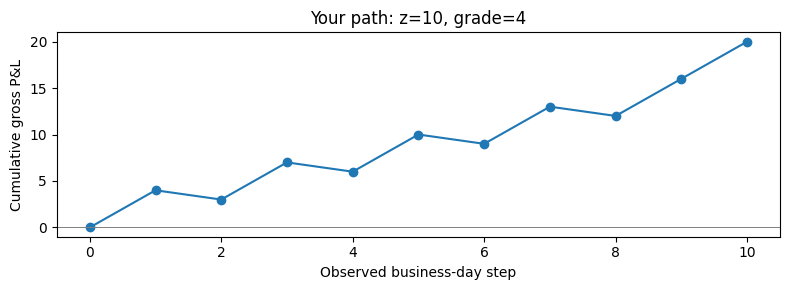

In [9]:
my_pnl = [4, -1, 4, -1, 4, -1, 4, -1, 4, 4]
my_result = shape_pnl(my_pnl)
my_grade = int(grades([my_result['z']], cuts)[0])
display(pd.Series({**my_result, 'grade': my_grade, 'gain': GAIN[my_grade]}, name='your_path').to_frame())
my_curve = np.r_[0., np.cumsum(my_pnl)]
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(np.arange(len(my_curve)), my_curve, marker='o')
ax.axhline(0, color='grey', linewidth=.7)
ax.set(xlabel='Observed business-day step', ylabel='Cumulative gross P&L',
       title=f"Your path: z={my_result['z']:.6g}, grade={my_grade}")
fig.tight_layout()
plt.show()

## 8. Executable arithmetic and timing checks

These checks verify the worked numerical examples and label boundaries. No
test depends on a trained model looking profitable.

In [10]:
def check_examples():
    np.testing.assert_array_equal(mark_example.short_pnl_increment.iloc[1:], [1., -2., 3., 3.])
    assert mark_example.short_pnl_increment.sum() == option_marks.iloc[0]-option_marks.iloc[-1]
    small = summary.loc['Small scattered losses']
    assert small.gross == 20 and small.downside == 2
    assert small.z == 20/(2+EPSILON)
    assert summary.loc['One deep loss', 'z'] == 20/(10+EPSILON)
    assert summary.loc['More profit, more risk', 'z'] < summary.loc['One deep loss', 'z']
    assert summary.loc['No losing day', 'z'] == 20/EPSILON
    assert summary.loc['SKIP', 'z'] == summary.loc['Break-even trade', 'z'] == 0
    assert summary.loc['Steady losing trade', 'z'] < summary.loc['Volatile losing trade', 'z'] < 0
    assert order_comparison.z.nunique() == 1
    np.testing.assert_array_equal(order_comparison.max_drawdown_pnl_units, [1., 4.])
    assert frequency_example.gross.eq(2).all()
    assert frequency_example.loc['Two aggregated increments', 'downside'] == 0
    assert historical.used_for_cuts.sum() == 2*len(toy_gross)
    assert not historical.loc[historical.secId.isna(), 'used_for_cuts'].any()
    assert historical.loc[historical.used_for_cuts, 'label_available'].lt(FIT_BOUNDARY).all()
    assert not historical.loc[historical.date.eq('2023-12-29'), 'used_for_cuts'].any()
    np.testing.assert_array_equal(grades(cuts, cuts), [0, 1, 2, 3])
    np.testing.assert_array_equal(grades(np.nextafter(cuts, np.inf), cuts), [1, 2, 3, 4])
    assert ranked.loc['SKIP', 'grade'] == grades([0.], cuts)[0]
    np.testing.assert_array_equal(ranked.gain, GAIN[ranked.grade])
    for invalid_path in [[], [1., np.nan], [np.inf], [[1., 2.]]]:
        try:
            shape_pnl(invalid_path)
        except ValueError:
            pass
        else:
            raise AssertionError('An invalid/incomplete path was accepted')
    print('PASS: P&L signs, shaping arithmetic, edge cases, frozen training cuts, grade ties and SKIP.')


check_examples()

PASS: P&L signs, shaping arithmetic, edge cases, frozen training cuts, grade ties and SKIP.
